In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
%matplotlib inline

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [4]:
sns.set_style('whitegrid')
pd.options.display.float_format = '{:,.2f}'.format

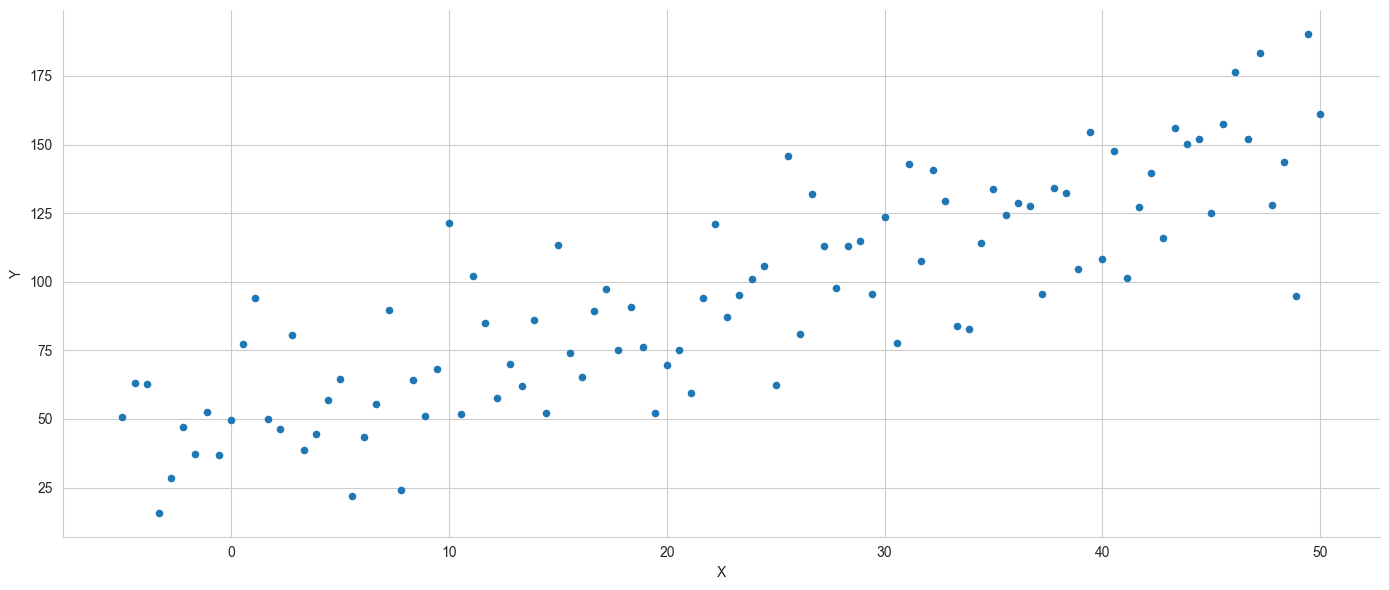

In [5]:
x = np.linspace(-5, 50, 100)
y = 50 + 2 * x + np.random.normal(0, 20, size=len(x))
data = pd.DataFrame({'X': x, 'Y': y})
ax = data.plot.scatter(x='X', y='Y', figsize=(14, 6))
sns.despine()
plt.tight_layout()

In [6]:
X = sm.add_constant(data['X'])
model = sm.OLS(data['Y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     234.7
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           9.32e-28
Time:                        19:42:42   Log-Likelihood:                -448.00
No. Observations:                 100   AIC:                             900.0
Df Residuals:                      98   BIC:                             905.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.1581      3.716     12.960      0.0

In [7]:
beta = np.linalg.inv(X.T.dot(X)).dot(X.T.dot(y))
pd.Series(beta, index=X.columns)

const   48.16
X        2.06
dtype: float64

Display model & residuals

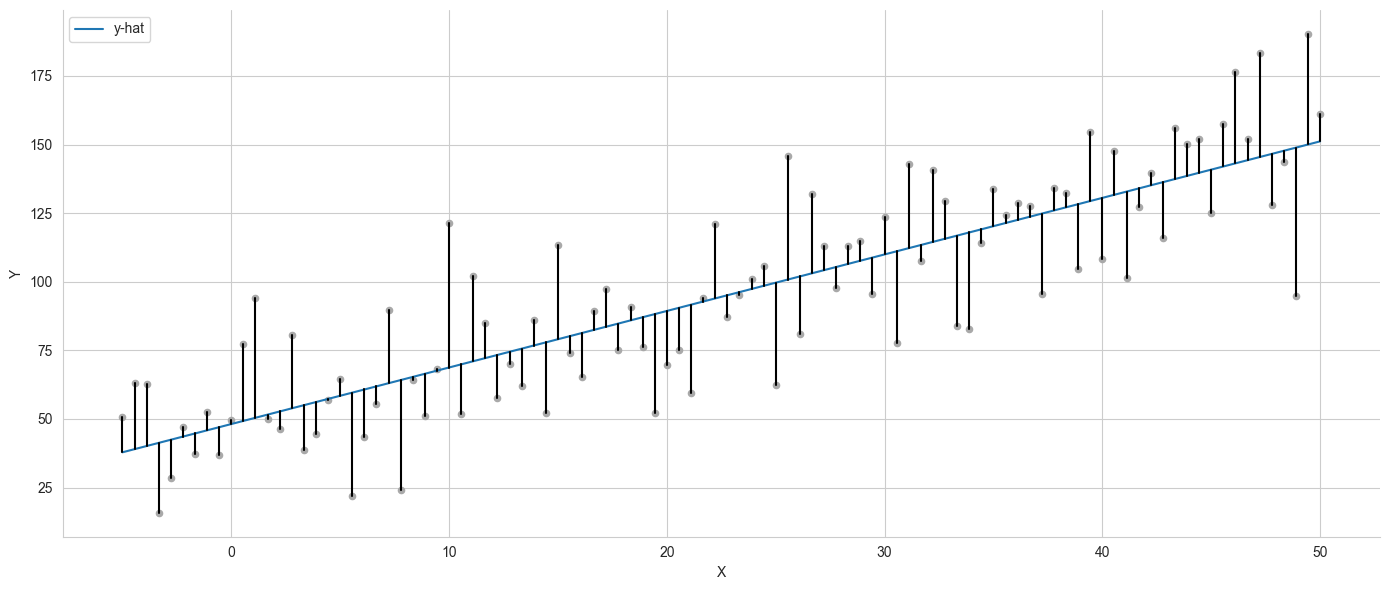

In [8]:
data['y-hat'] = model.predict()
data['residuals'] = model.resid
ax = data.plot.scatter(x='X', y='Y', c='darkgrey', figsize=(14,6))
data.plot.line(x='X', y='y-hat', ax=ax);
for _, row in data.iterrows():
    plt.plot((row.X, row.X), (row.Y, row['y-hat']), 'k-')    
sns.despine()
plt.tight_layout();

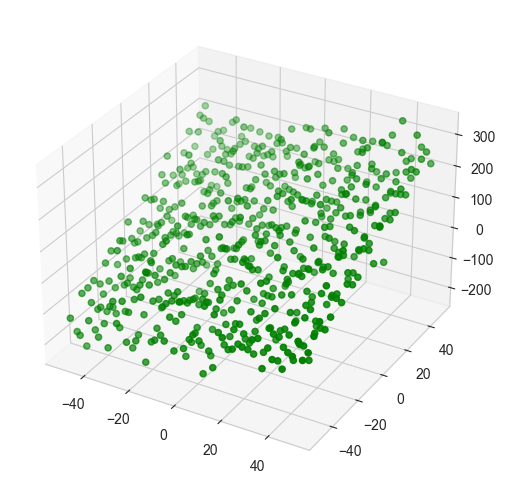

In [9]:
## Create data
size = 25
X_1, X_2 = np.meshgrid(np.linspace(-50, 50, size), np.linspace(-50, 50, size), indexing='ij')
data = pd.DataFrame({'X_1': X_1.ravel(), 'X_2': X_2.ravel()})
data['Y'] = 50 + data.X_1 + 3 * data.X_2 + np.random.normal(0, 50, size=size**2)

## Plot
fig = plt.figure(figsize=(15, 5))
three_dee = fig.add_subplot(111, projection='3d')
three_dee.scatter(data.X_1, data.X_2, data.Y, c='g')
plt.tight_layout()

In [10]:
X = data[['X_1', 'X_2']]
y = data['Y']

In [11]:
X_ols = sm.add_constant(X)
model = sm.OLS(y, X_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     1220.
Date:                Tue, 06 Jan 2026   Prob (F-statistic):          4.87e-216
Time:                        19:42:43   Log-Likelihood:                -3300.1
No. Observations:                 625   AIC:                             6606.
Df Residuals:                     622   BIC:                             6620.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.4997      1.906     26.501      0.0

# Tests de diagnóstico estadístico en Machine Learning (Python)

Estas notas resumen **tests clásicos que aparecen en regresión (OLS) y modelos estadísticos**, muy comunes en `statsmodels` y en análisis previo/posterior a modelos de ML.

---

## 1. Omnibus Test (Normalidad conjunta)

### ¿Qué es?
El **Omnibus test** es un test global de **normalidad de los residuos**.  
Combina información de **asimetría (skewness)** y **curtosis** en una sola estadística.

En `statsmodels` suele reportarse como:
- `Omnibus`
- `Prob(Omnibus)`

### Hipótesis
- **H₀ (nula):** los residuos siguen una distribución normal
- **H₁ (alternativa):** los residuos no son normales



---

## 2. Jarque–Bera (JB)

### ¿Qué es?
Test específico de **normalidad** basado explícitamente en:
- **Skewness = 0**
- **Kurtosis = 3**

Es más directo que Omnibus y muy usado en econometría.

### Hipótesis
- **H₀:** los residuos son normales
- **H₁:** los residuos no son normales

### Interpretación
- `p-value > α`: no se rechaza normalidad
- `p-value ≤ α`: residuos no normales

### Omnibus vs Jarque–Bera
- Ambos testean normalidad
- JB es más estándar y explícito
- Omnibus es una combinación más general

---

## 3. Durbin–Watson (Autocorrelación)

### ¿Qué es?
El **Durbin–Watson** detecta **autocorrelación de primer orden** en los residuos.

Muy importante en:
- Series temporales
- Regresiones con datos ordenados en el tiempo

### Rango del estadístico
$$
DW \in [0, 4]
$$

Interpretación práctica:
- **≈ 2** → no autocorrelación
- **< 2** → autocorrelación positiva
- **> 2** → autocorrelación negativa

### Hipótesis (implícitas)
- **H₀:** no hay autocorrelación
- **H₁:** existe autocorrelación

### ¿Qué pasa si se rechaza?
- Varianzas mal estimadas
- Tests t y p-values poco confiables
- Posibles soluciones:
  - Agregar rezagos
  - Modelos AR / GLS
  - Newey–West standard errors

---

## 4. Condition Number (Número de condición)

### ¿Qué es?
El **condition number** mide la **estabilidad numérica** de la matriz de diseño \(X\).

Está relacionado con:
- **Multicolinealidad**
- Sensibilidad a pequeños cambios en los datos

### Regla práctica
- `< 30` → bien condicionado
- `30 – 100` → cuidado
- `> 100` → **multicolinealidad seria**

### No es un test de hipótesis
- **No hay p-value**
- Es una **medida diagnóstica**, no un test estadístico formal

### Consecuencias de un número alto
- Coeficientes inestables
- Signos que cambian
- Grandes errores estándar

### Posibles soluciones
- Eliminar variables redundantes
- Regularización (Ridge, Lasso)
- PCA / reducción de dimensión
- Reescalar variables

In [ ]:
## Create data
size = 25
X_1, X_2 = np.meshgrid(np.linspace(-50, 50, size), np.linspace(-50, 50, size), indexing='ij')
data = pd.DataFrame({'X_1': X_1.ravel(), 'X_2': X_2.ravel()})
data['Y'] = 50 + data.X_1 + 3 * data.X_2 + np.random.normal(0, 50, size=size**2)

## Plot
fig = plt.figure(figsize=(15, 5))
three_dee = fig.add_subplot(111, projection='3d')
three_dee.scatter(data.X_1, data.X_2, data.Y, c='g')
plt.tight_layout()

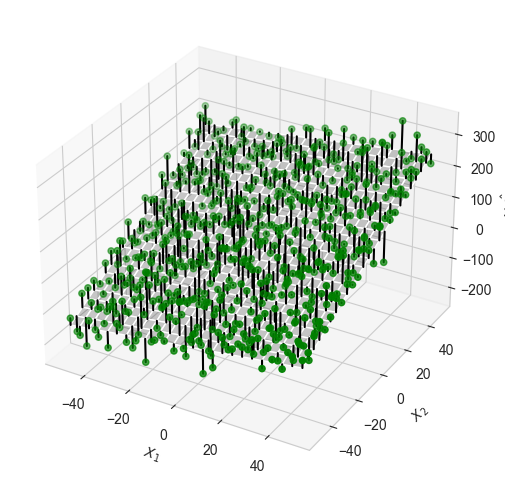

In [13]:
fig = plt.figure(figsize=(15, 5))
three_dee = fig.add_subplot(111, projection = '3d')
three_dee.scatter(data.X_1, data.X_2, data.Y, c='g')
data['y-hat'] = model.predict()
to_plot = data.set_index(['X_1', 'X_2']).unstack().loc[:, 'y-hat']
three_dee.plot_surface(X_1, X_2, to_plot.values, color='black', alpha=0.2, linewidth=1, antialiased=True)
for _, row in data.iterrows():
    plt.plot((row.X_1, row.X_1), (row.X_2, row.X_2), (row.Y, row['y-hat']), 'k-');
three_dee.set_xlabel('$X_1$');three_dee.set_ylabel('$X_2$');three_dee.set_zlabel('$Y, \hat{Y}$')
sns.despine()
plt.tight_layout();

## Stochastic Gradient Descent Regression

The sklearn library includes an SGDRegressor model in its linear_models module. To learn the parameters for the same model using this method, we need to first standardize the data because the gradient is sensitive to the scale.

### Prepare data

We use StandardScaler() for this purpose that computes the mean and the standard deviation for each input variable during the fit step, and then subtracts the mean and divides by the standard deviation during the transform step that we can conveniently conduct in a single fit_transform() command:

In [14]:
scaler = StandardScaler()
X_ = scaler.fit_transform(X)

## Configure SGDRegressor

Then we instantiate the SGDRegressor using the default values except for a random_state setting to facilitate replication:

In [17]:
sgd = SGDRegressor(loss='squared_error', 
                   fit_intercept=True, 
                   shuffle=True, 
                   random_state=42,
                   learning_rate='invscaling', 
                   eta0=0.01, 
                   power_t=0.25)

### Fit Model
Now we can fit the sgd model, create the in-sample predictions for both the OLS and the sgd models, and compute the root mean squared error for each:

In [18]:
# sgd.n_iter = np.ceil(10**6 / len(y))
sgd.fit(X=X_, y=y, )

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


As expected, both models yield the same result. We will now take on a more ambitious project using linear regression to estimate a multi-factor asset pricing model.

In [19]:
coeffs = (sgd.coef_ * scaler.scale_) + scaler.mean_
pd.Series(coeffs, index=X.columns)

X_1     866.02
X_2   2,693.44
dtype: float64

In [20]:
resids = pd.DataFrame({'sgd': y - sgd.predict(X_),
                      'ols': y - model.predict(sm.add_constant(X))})

In [21]:
resids.pow(2).sum().div(len(y)).pow(.5)

sgd   47.53
ols   47.53
dtype: float64

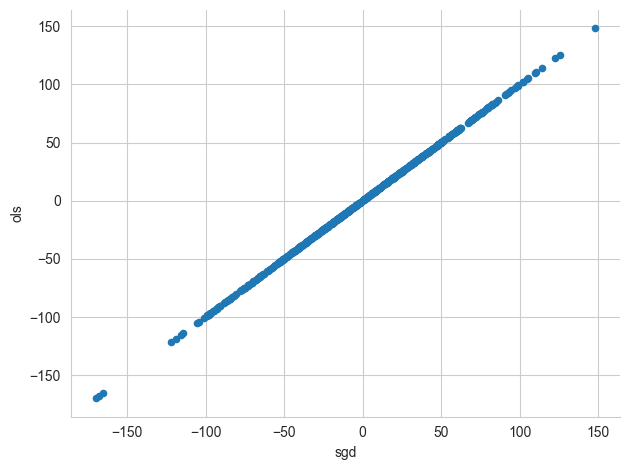

In [22]:
resids.plot.scatter(x='sgd', y='ols')
sns.despine()
plt.tight_layout();